# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [1]:
import numpy as np

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1308s 8us/step


In [2]:
from tensorflow import keras

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


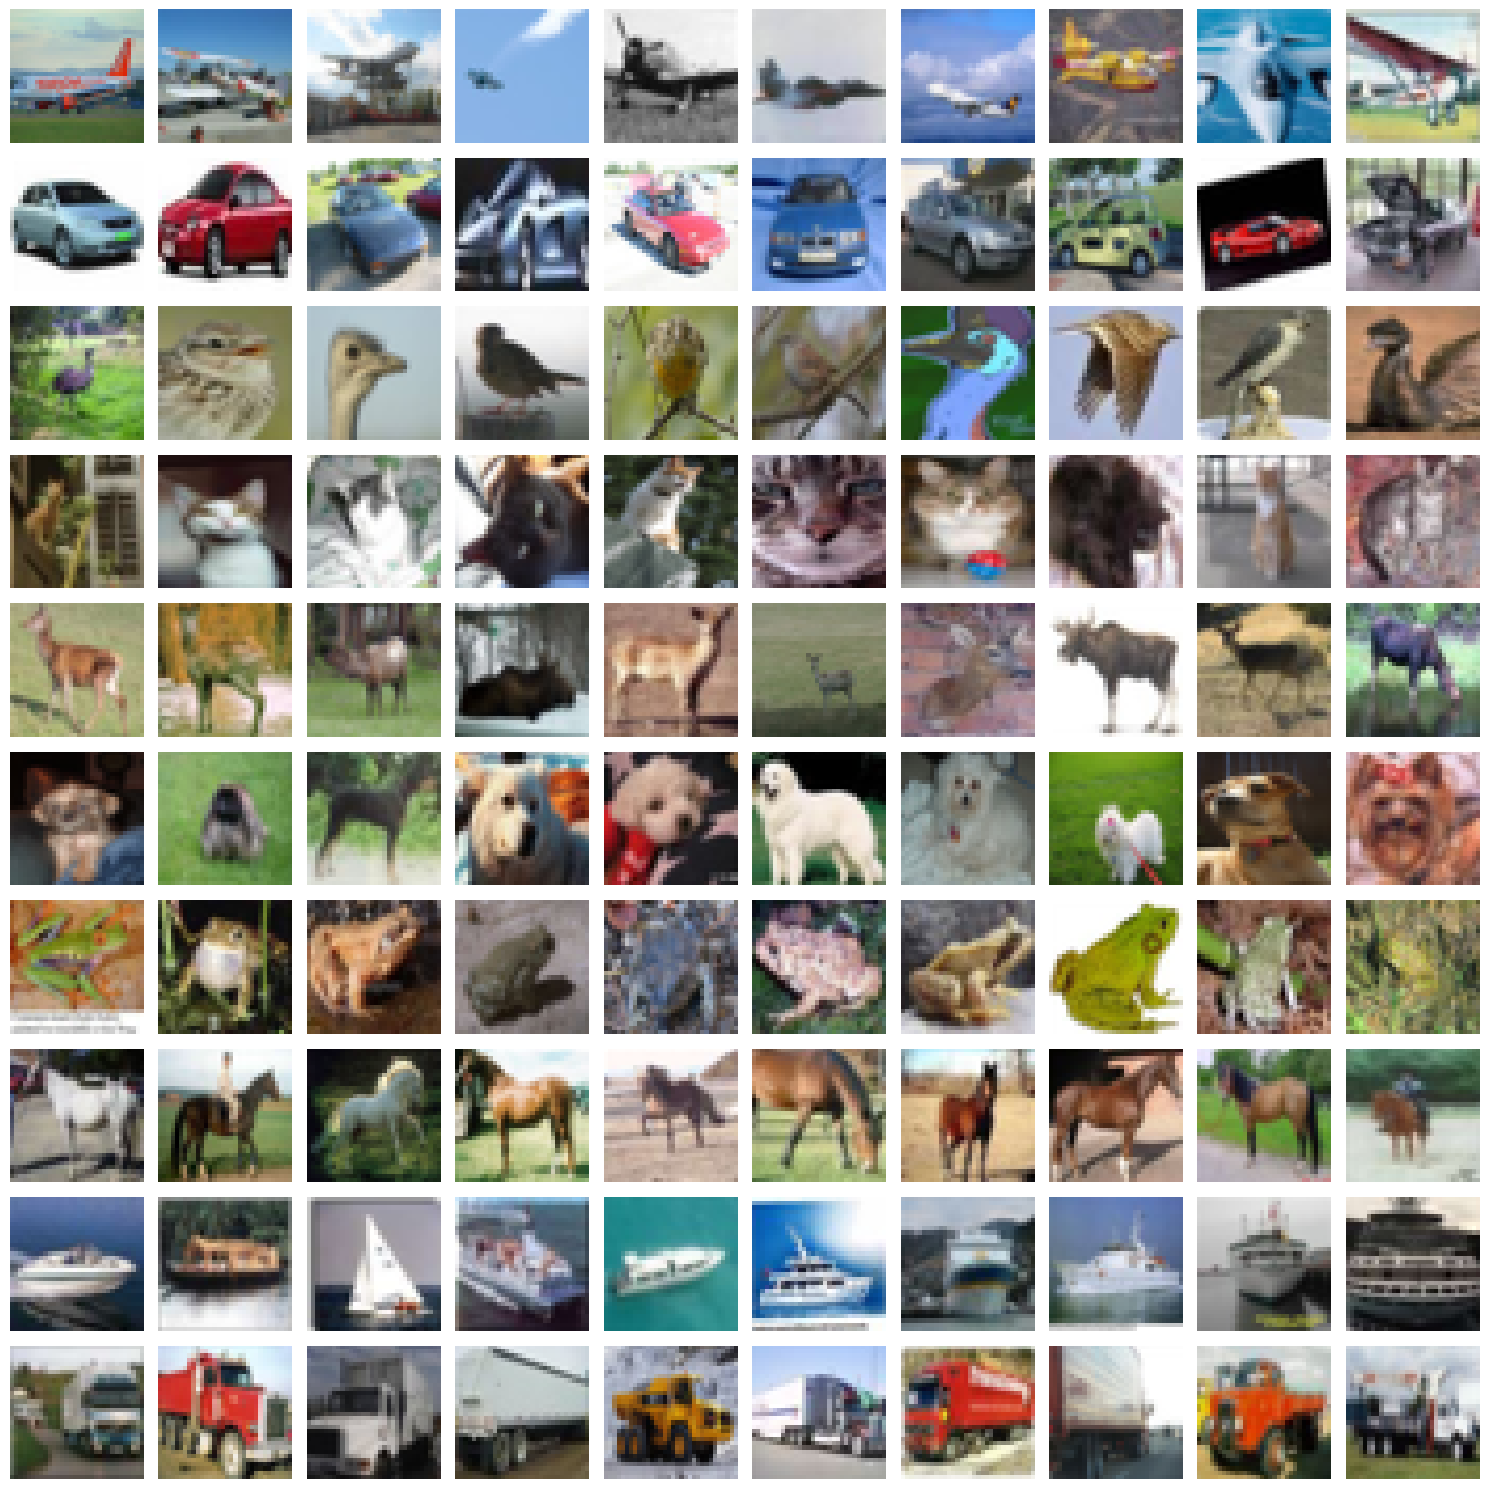

In [ ]:
class_names = [
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck"
]

fig, axes = plt.subplots(10, 10, figsize=(15, 15))

for class_id in range(10):


    indices = np.where(y_train.flatten() == class_id)[0]


    random_indices = np.random.choice(indices, 10, replace=False)


    for j, index in enumerate(random_indices):
        axes[class_id, j].imshow(x_train[index])
        axes[class_id, j].axis("off")


    axes[class_id, 0].set_ylabel(
        class_names[class_id],
        rotation=0,
        labelpad=40
    )

plt.tight_layout()
plt.show() 

In [4]:
y_train_one_hot = to_categorical(y_train, 10)
y_test_one_hot = to_categorical(y_test, 10)

print(y_train[3])
print(y_train_one_hot[3])

[4]
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

print(x_train.min())
print(x_train.max())

0.0
1.0


## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer.

Use the input as (32,32,3).

The filter maps can then be flattened to provide features to the classifier.

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [6]:
from keras.backend import clear_session
clear_session()

In [9]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),

    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(100, activation="relu"),

    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [10]:
model.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

In [11]:
history = model.fit(
    x_train,
    y_train_one_hot,
    epochs=50,
    batch_size=512
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.1779 - loss: 2.2383
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2486 - loss: 2.1229
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2941 - loss: 2.0230
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3200 - loss: 1.9477
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3392 - loss: 1.9005
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3493 - loss: 1.8651
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3600 - loss: 1.8380
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3686 - loss: 1.8125
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3779 - loss: 1.7877
Epoch 10/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3850 - loss: 1.7655
Epoch 11/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3957 - loss: 1.7408
Epoch 12/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.40

*   Plot the cross entropy loss curve and the accuracy curve

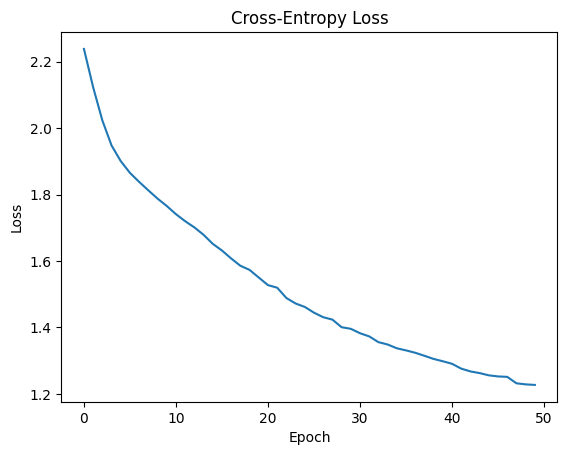

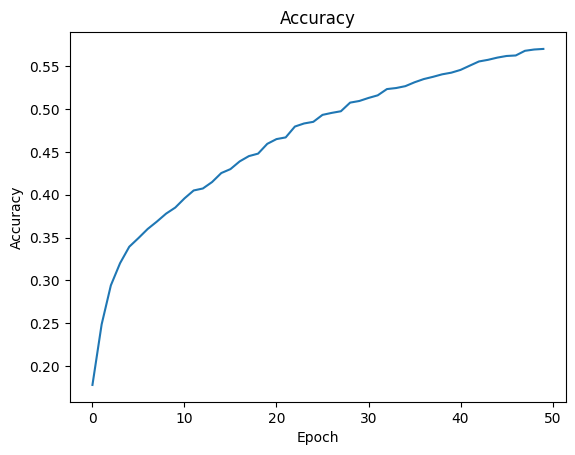

In [12]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Cross-Entropy Loss")
plt.show()

plt.plot(history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.show()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 814,378 (3.11 MB)

 Trainable params: 814,378 (3.11 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - accuracy: 0.1407 - loss: 2.2734
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.2374 - loss: 2.1493
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.2874 - loss: 2.0118
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3101 - loss: 1.9530
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3332 - loss: 1.8983
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3469 - loss: 1.8605
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3612 - loss: 1.8248
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.3692 - loss: 1.7930
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3798 - loss: 1.7680
Epoch 10/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.3886 - loss: 1.7396
Epoch 11/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.3984 - loss: 1.7070
Epoch 12/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy:

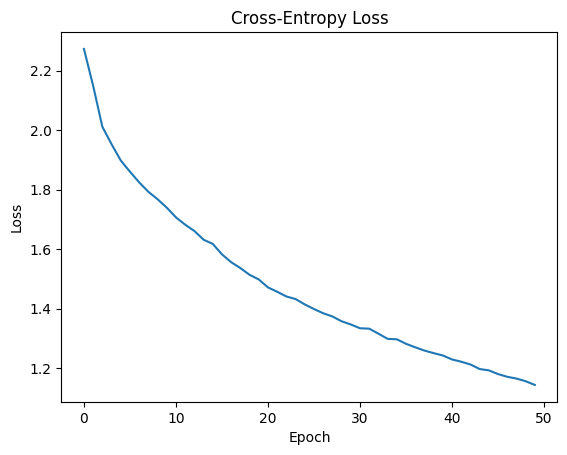

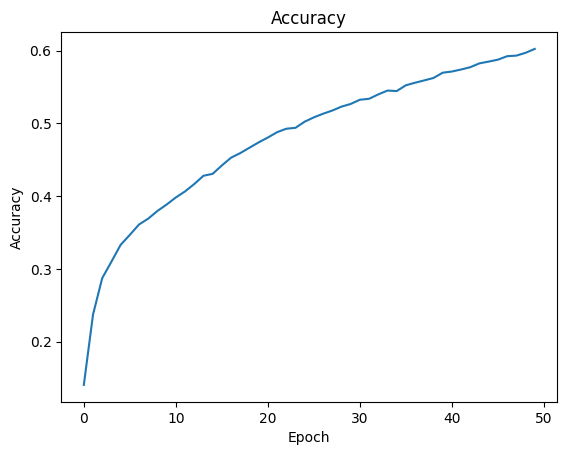

In [15]:
model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),

    layers.Conv2D(32, kernel_size=(3, 3), activation="relu"),

    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dense(10, activation="softmax")
])

model.summary()

model.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"])

history = model.fit(
    x_train,
    y_train_one_hot,
    epochs=50,
    batch_size=512
)

plt.plot(history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Cross-Entropy Loss")
plt.show()

plt.plot(history.history["accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.show()


## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3.

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [13]:
from keras.backend import clear_session
clear_session()

In [17]:
model_vgg = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),

    layers.Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.Conv2D(
        32,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),

    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dense(10, activation="softmax")
])

model_vgg.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,138 (4.04 MB)

 Trainable params: 1,060,138 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [18]:
model_vgg.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

history_vgg = model_vgg.fit(
    x_train,
    y_train_one_hot,
    epochs=50,
    batch_size=512
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 8s 51ms/step - accuracy: 0.1679 - loss: 2.2590
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.2631 - loss: 2.0980
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3020 - loss: 1.9802
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3364 - loss: 1.9038
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3546 - loss: 1.8483
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3721 - loss: 1.8020
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3820 - loss: 1.7675
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3959 - loss: 1.7257
Epoch 9/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4025 - loss: 1.7039
Epoch 10/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.4118 - loss: 1.6765
Epoch 11/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4210 - loss: 1.6505
Epoch 12/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy:

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.


In [ ]:
The deeper VGG model achieved a similar performance to the intermediate model, which already used two convolutional layers and increased the dense layer to 128 units. The first modification, adding a second convolutional layer, produced a more noticeable improvement compared with the original model. Overall, increasing the depth beyond this point did not lead to a significant additional improvement in this exsercise.

**Comment on the observation**

The deeper VGG model achieved a similar performance to the intermediate model, which already used two convolutional layers and increased the dense layer to 128 units. The first modification, adding a second convolutional layer, produced a more noticeable improvement compared with the original model. Overall, increasing the depth beyond this point did not lead to a significant additional improvement in this experiment.

...

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


In [19]:
y_pred_prob = model_vgg.predict(x_test)

y_pred = y_pred_prob.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


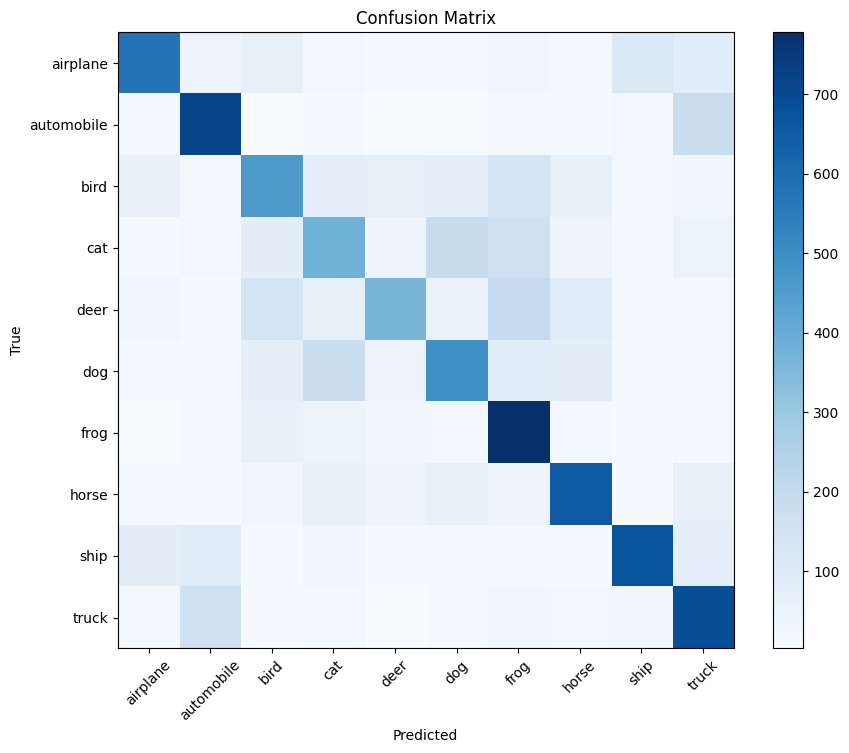

In [20]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test.flatten(),
    y_pred
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

**Comment here :**

*(Double-click or enter to edit)*

...

*    Print the test accuracy for the trained model.

In [21]:
from sklearn.metrics import accuracy_score

test_accuracy = accuracy_score(
    y_test.flatten(),
    y_pred
)

print("Test accuracy:", test_accuracy)

Test accuracy: 0.579


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer.

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling.

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [ ]:
from keras.backend import clear_session
clear_session()

In [22]:
import tensorflow as tf

x_train = tf.image.resize(x_train, (64, 64))
x_test = tf.image.resize(x_test, (64, 64))

print(x_train.shape)
print(x_test.shape)

(50000, 64, 64, 3)
(10000, 64, 64, 3)


In [23]:
model_vgg = keras.Sequential([

    keras.Input(shape=(64, 64, 3)),

    # BLOCCO 1
    layers.Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.Conv2D(
        64,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),


    # BLOCCO 2
    layers.Conv2D(
        128,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.Conv2D(
        128,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),


    # BLOCCO 3
    layers.Conv2D(
        256,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.Conv2D(
        256,
        kernel_size=(3, 3),
        activation="relu",
        padding="same"
    ),

    layers.MaxPooling2D(pool_size=(2, 2)),


    # CLASSIFICATORE
    layers.Flatten(),

    layers.Dense(128, activation="relu"),

    layers.Dense(10, activation="softmax")
])

model_vgg.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model_vgg.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

In [26]:
model_vgg.compile(
    loss="categorical_crossentropy",
    optimizer="sgd",
    metrics=["accuracy"]
)

history_vgg = model_vgg.fit(
    x_train,
    y_train_one_hot,
    epochs=10,
    batch_size=512
)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 47s 462ms/step - accuracy: 0.5840 - loss: 1.1886
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 41s 422ms/step - accuracy: 0.5905 - loss: 1.1721
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 428ms/step - accuracy: 0.6003 - loss: 1.1433
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 425ms/step - accuracy: 0.6046 - loss: 1.1246
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 425ms/step - accuracy: 0.6161 - loss: 1.0994
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 428ms/step - accuracy: 0.6271 - loss: 1.0704
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 427ms/step - accuracy: 0.6332 - loss: 1.0545
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 426ms/step - accuracy: 0.6414 - loss: 1.0297
Epoch 9/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 424ms/step - accuracy: 0.6510 - loss: 1.0045
Epoch 10/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 425ms/step - accuracy: 0.6633 - loss: 0.9716


313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step


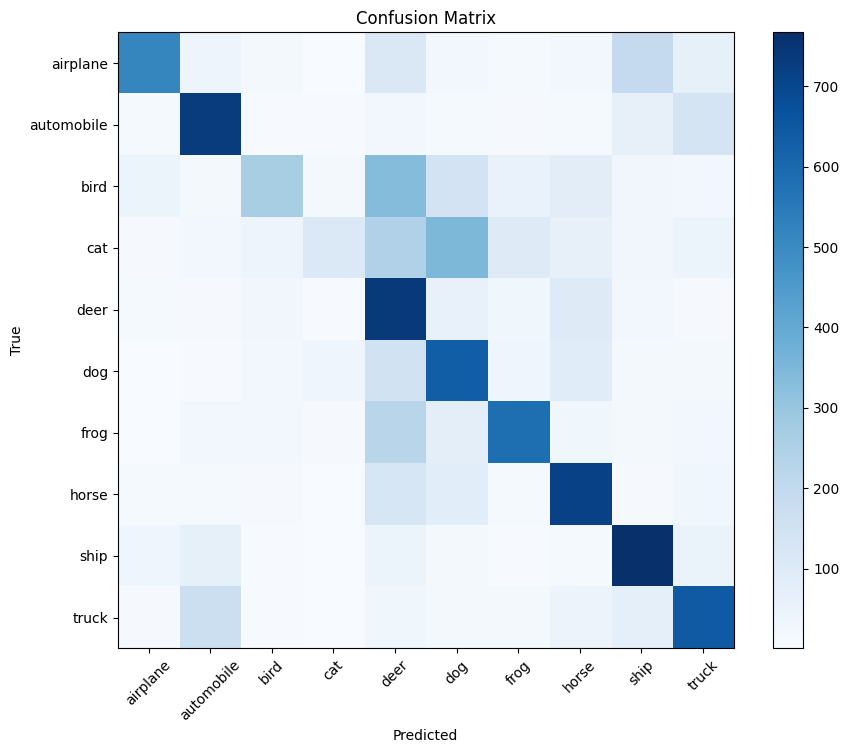

In [27]:
y_pred_prob = model_vgg.predict(x_test)

y_pred = y_pred_prob.argmax(axis=1)

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test.flatten(),
    y_pred
)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks(range(10), class_names, rotation=45)
plt.yticks(range(10), class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")

plt.show()

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:

we use them to use non-linear function into the neural network. the network in this way learn more complex interaction.

_

2 - Key Differences between sigmoid and softmax:

sigmoid -> tell us the percentage something is what we are inquiring or not.

softmax -> we see how the algorithm spread among a list the probability.

_

3 - Key Differences between categorical crossentropy and binary crossentropy loss:

we move from binary results ,eg. yes/no, to a categorical multi classification.
_


In [28]:
!git status

fatal: not a git repository (or any of the parent directories): .git


In [30]:
!pwd
!ls -la

/content
total 16
drwxr-xr-x 1 root root 4096 Sep  4 13:32 .
drwxr-xr-x 1 root root 4096 Sep 29 12:14 ..
drwxr-xr-x 4 root root 4096 Sep  4 13:32 .config
drwxr-xr-x 1 root root 4096 Sep  4 13:32 sample_data


In [31]:
!git clone https://github.com/ivanmatteuzzi/lab-image-classification-using-convolutional-neural-networks.git

Cloning into 'lab-image-classification-using-convolutional-neural-networks'...
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (2/2), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 4 (delta 0), reused 0 (delta 0), pack-reused 2 (from 1)
Receiving objects: 100% (4/4), done.


In [32]:
!ls

lab-image-classification-using-convolutional-neural-networks  sample_data


In [33]:
%cd /content/lab-image-classification-using-convolutional-neural-networks

/content/lab-image-classification-using-convolutional-neural-networks


In [34]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean


In [35]:
!ls -la

total 28
drwxr-xr-x 3 root root 4096 Sep 29 15:37 .
drwxr-xr-x 1 root root 4096 Sep 29 15:37 ..
drwxr-xr-x 8 root root 4096 Sep 29 15:38 .git
-rw-r--r-- 1 root root 9641 Sep 29 15:37 main.ipynb
-rw-r--r-- 1 root root  630 Sep 29 15:37 README.md


In [36]:
!ls -lh /content/*.ipynb

ls: cannot access '/content/*.ipynb': No such file or directory
